# Introdução à visualização de dados com Python 
## Explorando dados abertos de Lisboa
#### Monitorização de Parâmetros Ambientais da Cidade de Lisboa - Histórico 15/07/2021 a 15/01/2024

In [29]:
import pandas as pd

In [30]:
df = pd.read_csv("condicionamentos_lisboaaberta.csv")
df.head()

,creation_date,entity_id,position,impacto,morada,motivo,periodos_condicionamentos,restricao_circulacao,periodos_condicionamentos['date_max']
0,2024-10-14T10:11:57.000Z,EMEL.condicionamentoTransito.COND-2024-1403-PA-17,"{""type"":""GeometryCollection"",""geometries"":[{""c...",Relevante,R. Jorge Castilho n.º 26-28 / Avª. Afonso Cost...,CARGAS E DESCARGAS/OBRAS,"[{""end_date"":""1731600000000"",""date_min"":""2024-...",Estreitamento de via,"[""2024-11-14""]"
1,2024-10-08T09:42:35.000Z,EMEL.condicionamentoTransito.COND-2024-1419-PA-17,"{""type"":""GeometryCollection"",""geometries"":[{""c...",Relevante,"Rua da Prata,174-178",CARGAS E DESCARGAS/OBRAS,"[{""end_date"":""1731657600000"",""date_min"":""2024-...",Passeio,"[""2024-11-15"",""2024-11-15""]"
2,2024-01-03T15:48:22.000Z,EMEL.condicionamentoTransito.COND-2024-14-1,"{""type"":""GeometryCollection"",""geometries"":[{""c...",Relevante,Rua da Cintura do Porto de Lisboa / Término do...,RESERVA DE ESTACIONAMENTO,"[{""end_date"":""1734307140000"",""date_min"":""2024-...",Estacionamento,"[""2024-12-15""]"
3,2024-10-01T15:08:12.000Z,EMEL.condicionamentoTransito.COND-2024-5918-1,"{""type"":""GeometryCollection"",""geometries"":[{""c...",Relevante,Túnel do Marquês,OBRA - FAIXA DE RODAGEM,"[{""end_date"":""1730268000000"",""date_min"":""2024-...",Corte total,"[""2024-10-30"",""2024-10-31""]"
4,2024-10-14T10:19:28.000Z,EMEL.condicionamentoTransito.COND-2024-4914-PA-5,"{""type"":""GeometryCollection"",""geometries"":[{""c...",Relevante,Estrada da Torre S/N,CARGAS E DESCARGAS/OBRAS,"[{""end_date"":""1730824200000"",""date_min"":""2024-...",Estreitamento de via,"[""2024-11-05""]"


In [31]:
df.dtypes

creation_date                            object
entity_id                                object
position                                 object
impacto                                  object
morada                                   object
motivo                                   object
periodos_condicionamentos                object
restricao_circulacao                     object
periodos_condicionamentos['date_max']    object
dtype: object

In [32]:
df["motivo"].value_counts()

motivo
CARGAS E DESCARGAS/OBRAS                    820
BETONAGENS/CARGAS DESCARGAS                 524
OBRA - FAIXA DE RODAGEM                     488
CARGAS E DESCARGAS                          236
RESERVA DE ESTACIONAMENTO                   220
OBRA - PASSEIO E ESTACION.                  176
LIGAÇÃO DE RAMAL - PASSEIO E ESTACION.      148
ACESSO DE VEÍCULOS À OBRA                    96
MUDANÇAS                                     76
LIGAÇÃO DE RAMAL - FAIXA DE RODAGEM          76
PLANTAÇÃO / PODA DE ÁRVORES                  60
BETONAGENS                                   56
PINTURAS                                     52
EVENTO                                       46
FILMAGENS                                    44
AUTOGRUA                                     44
CONCENTRAÇÃO                                 44
OBRAS NO SUBSOLO - PASSEIO E ESTACION.       40
OBRAS NO SUBSOLO - FAIXA DE RODAGEM          32
SONDAGENS - PASSEIO E ESTACION.              28
REPAVIMENTAÇÕES                  

<AxesSubplot: title={'center': 'Top 10 motivos de condicionamentos de trânsito'}, ylabel='motivo'>

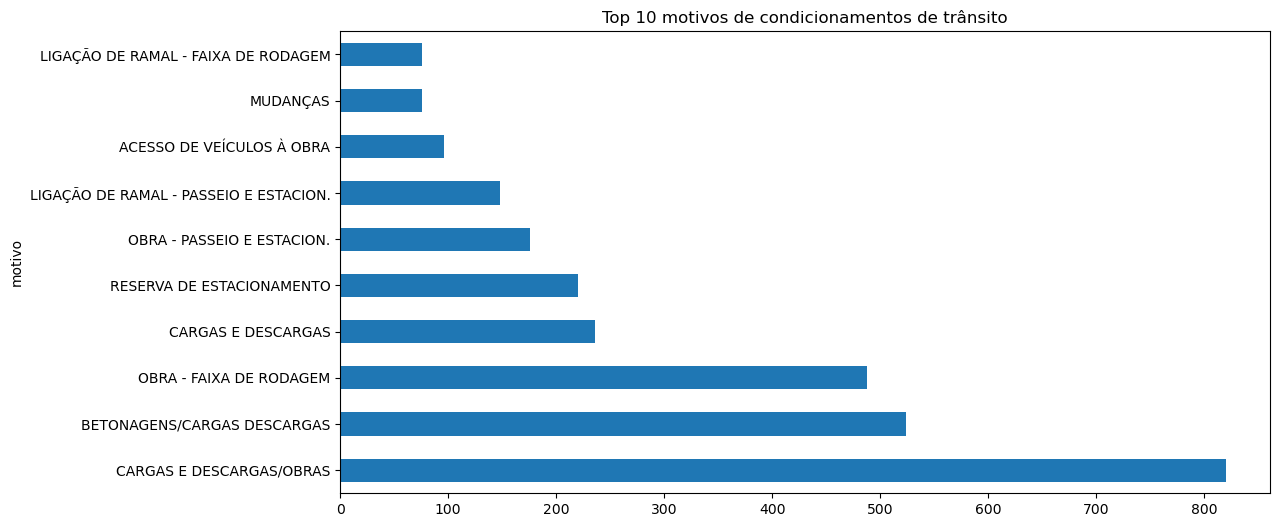

In [33]:
df["motivo"].value_counts().head(10).plot(
    kind="barh",
    figsize=(12, 6),
    title="Top 10 motivos de condicionamentos de trânsito"
)

In [34]:
df_obras = df[df["motivo"].str.contains("OBRA", case=False, na=False)]
df_obras.head()

,creation_date,entity_id,position,impacto,morada,motivo,periodos_condicionamentos,restricao_circulacao,periodos_condicionamentos['date_max']
0,2024-10-14T10:11:57.000Z,EMEL.condicionamentoTransito.COND-2024-1403-PA-17,"{""type"":""GeometryCollection"",""geometries"":[{""c...",Relevante,R. Jorge Castilho n.º 26-28 / Avª. Afonso Cost...,CARGAS E DESCARGAS/OBRAS,"[{""end_date"":""1731600000000"",""date_min"":""2024-...",Estreitamento de via,"[""2024-11-14""]"
1,2024-10-08T09:42:35.000Z,EMEL.condicionamentoTransito.COND-2024-1419-PA-17,"{""type"":""GeometryCollection"",""geometries"":[{""c...",Relevante,"Rua da Prata,174-178",CARGAS E DESCARGAS/OBRAS,"[{""end_date"":""1731657600000"",""date_min"":""2024-...",Passeio,"[""2024-11-15"",""2024-11-15""]"
3,2024-10-01T15:08:12.000Z,EMEL.condicionamentoTransito.COND-2024-5918-1,"{""type"":""GeometryCollection"",""geometries"":[{""c...",Relevante,Túnel do Marquês,OBRA - FAIXA DE RODAGEM,"[{""end_date"":""1730268000000"",""date_min"":""2024-...",Corte total,"[""2024-10-30"",""2024-10-31""]"
4,2024-10-14T10:19:28.000Z,EMEL.condicionamentoTransito.COND-2024-4914-PA-5,"{""type"":""GeometryCollection"",""geometries"":[{""c...",Relevante,Estrada da Torre S/N,CARGAS E DESCARGAS/OBRAS,"[{""end_date"":""1730824200000"",""date_min"":""2024-...",Estreitamento de via,"[""2024-11-05""]"
6,2024-06-27T08:51:25.000Z,EMEL.condicionamentoTransito.COND-2024-3960-2,"{""type"":""GeometryCollection"",""geometries"":[{""c...",Relevante,"Rua Padre Américo, N.º 4 - 22 {e entroncament...",OBRA - FAIXA DE RODAGEM,"[{""end_date"":""1730394000000"",""date_min"":""2024-...",Estreitamento de via,"[""2024-10-31""]"


In [35]:
df_obras["restricao_circulacao"].value_counts()

restricao_circulacao
Estreitamento de via    780
Estacionamento          364
Passeio                 176
Corte total             120
Cortes temporários      112
Mantém perfil de via     92
Corte num sentido         8
Name: count, dtype: int64

<AxesSubplot: title={'center': 'Tipos de restrição em condicionamentos por obras'}, ylabel='restricao_circulacao'>

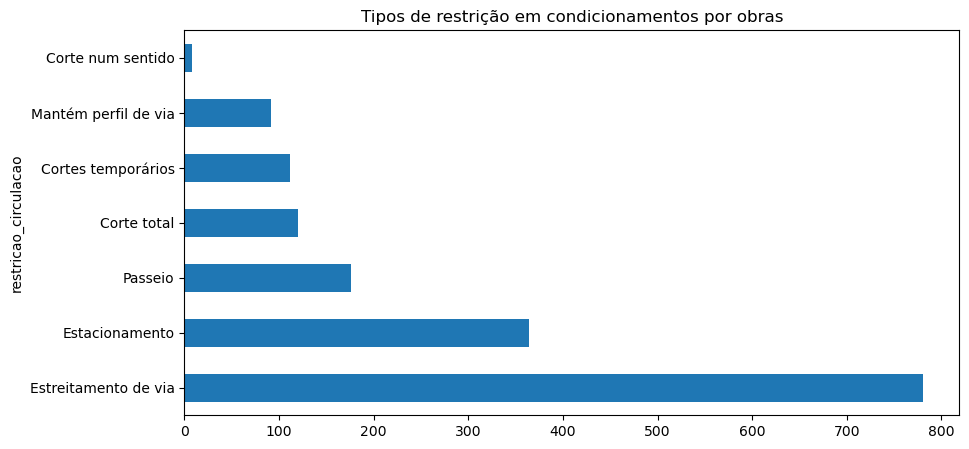

In [36]:
df_obras["restricao_circulacao"].value_counts().plot(
    kind="barh",
    figsize=(10, 5),
    title="Tipos de restrição em condicionamentos por obras"
)

<AxesSubplot: ylabel='count'>

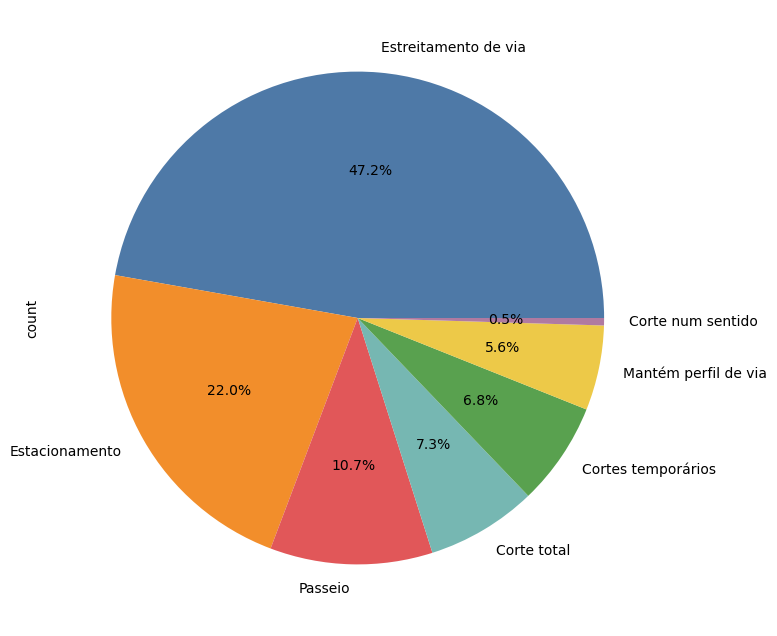

In [37]:
df_obras["restricao_circulacao"].value_counts().plot(
    kind="pie",
    figsize=(8, 8),
    colors=["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f", "#edc948", "#b07aa1"],
    autopct="%1.1f%%",
)